# HLA Allele Embedding Exploration

**Purpose:** Validate that ESM-2 protein language model embeddings capture biologically
meaningful HLA structure. Key questions:

1. Do alleles from different loci (A, B, C, DRB1) cluster separately in embedding space?
2. Within a locus, do alleles from the same antigen group cluster together?
3. Is the cosine similarity matrix consistent with known HLA serological relationships?

**Data source:** Embeddings pre-computed by `scripts/compute_embeddings.py` and cached
in `data/processed/hla_embeddings.h5`. Allele set derived from
`capa.data.hla_parser.ANTIGEN_TO_COMMON_ALLELE` — the 98 clinically relevant alleles
that correspond to the serological HLA typing for pediatric HSCT patients.

**Figures saved to:** `paper/figures/`

In [1]:
"""Environment setup."""
import sys
from pathlib import Path

# Make project root importable when running from notebooks/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /Users/huanxuan/Desktop/projects/capa


In [2]:
"""Imports."""
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist
from sklearn.preprocessing import normalize
import umap

print(f"numpy {np.__version__}, umap {umap.__version__}")

Matplotlib is building the font cache; this may take a moment.


numpy 2.4.4, umap 0.5.11


In [3]:
"""Publication-quality matplotlib style (Nature-inspired)."""

FIGURE_DPI = 300
FIGURES_DIR = ROOT / "paper" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Nature / Cell style: clean, minimal, high-contrast
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.title_fontsize": 8,
    # Lines & markers
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    # Grid
    "axes.grid": False,
    # Spines
    "axes.spines.top": False,
    "axes.spines.right": False,
    # Save
    "savefig.dpi": FIGURE_DPI,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    # PDF backend (vector)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Locus color palette (colorblind-friendly, distinct enough for UMAP)
LOCUS_COLORS = {
    "A":    "#E63946",   # vivid red
    "B":    "#457B9D",   # steel blue
    "C":    "#2D9E5A",   # forest green
    "DRB1": "#F4A11D",  # amber
    "DQB1": "#9B5DE5",  # violet
    "DPB1": "#888888",  # grey (not usually shown)
}

def save_fig(fig: plt.Figure, name: str) -> None:
    """Save figure at 300 DPI as both PNG and PDF."""
    for ext in ("png", "pdf"):
        path = FIGURES_DIR / f"{name}.{ext}"
        fig.savefig(path, dpi=FIGURE_DPI)
        print(f"  Saved {path.relative_to(ROOT)}")

print(f"Figures → {FIGURES_DIR}")

Figures → /Users/huanxuan/Desktop/projects/capa/paper/figures


## 1. Load Embeddings

In [4]:
"""Load all cached embeddings, optionally computing missing ones."""
import h5py
from capa.data.hla_parser import ANTIGEN_TO_COMMON_ALLELE
from capa.embeddings.cache import EmbeddingCache

CACHE_PATH = ROOT / "data" / "processed" / "hla_embeddings.h5"
SEQ_PATH   = ROOT / "data" / "processed" / "hla_sequences.json"

TARGET_LOCI = ["A", "B", "C", "DRB1", "DQB1"]

# Unique alleles for target loci from the antigen→allele mapping
loci_set = set(TARGET_LOCI)
target_alleles: set[str] = {
    allele
    for allele in ANTIGEN_TO_COMMON_ALLELE.values()
    if "*" in allele and allele.split("*")[0] in loci_set
}

cache = EmbeddingCache(CACHE_PATH)
cached = set(cache.cached_alleles())
available = sorted(target_alleles & cached)
missing   = sorted(target_alleles - cached)

print(f"Target alleles : {len(target_alleles)}")
print(f"In cache       : {len(available)}")
print(f"Missing        : {len(missing)}")
if missing:
    print("\nMissing alleles (will attempt to compute):")
    for a in missing:
        print(f"  {a}")

Target alleles : 98
In cache       : 98
Missing        : 0


In [5]:
"""Compute any missing embeddings (uses cached ESM-2 weights if already downloaded)."""
if missing and SEQ_PATH.exists():
    print(f"Computing {len(missing)} missing embeddings — this may take several minutes on CPU.")
    from capa.embeddings.hla_sequences import HLASequenceDB
    from capa.embeddings.esm_embedder import ESMEmbedder

    seq_db = HLASequenceDB(SEQ_PATH)
    miss_seqs = {}
    for allele in missing:
        try:
            miss_seqs[allele] = seq_db.get_by_name(allele)
        except KeyError:
            print(f"  WARNING: no sequence for {allele}")

    if miss_seqs:
        embedder = ESMEmbedder(device=None, batch_size=4)
        result = cache.embed_alleles(miss_seqs, embedder, show_progress=True)
        available = sorted(target_alleles & set(cache.cached_alleles()))
        print(f"\nEmbeddings now in cache: {len(cache)}")
elif missing:
    print(f"Sequence database not found at {SEQ_PATH}.")
    print("Run: uv run python scripts/download_hla_seqs.py")
    print(f"Proceeding with {len(available)} cached alleles.")
else:
    print("All target alleles are cached — no computation needed.")

All target alleles are cached — no computation needed.


In [6]:
"""Build the embedding matrix and metadata DataFrame."""

# Rebuild available list after potential new computations
available = sorted(target_alleles & set(cache.cached_alleles()))

embeddings = np.stack([cache.get(a) for a in available])  # (N, 1280)

# --- Metadata ---
def _locus(allele: str) -> str:
    return allele.split("*")[0]

def _antigen_group(allele: str) -> str:
    """Return the two-field allele string used as antigen group label."""
    gene, rest = allele.split("*", 1)
    fields = rest.split(":")
    return f"{gene}*{fields[0]}"          # e.g. "A*02" → group for A*02:01, A*02:06 …

def _short_label(allele: str) -> str:
    """Remove gene prefix for compact tick labels (e.g. 'A*02:01' → '02:01')."""
    return allele.split("*", 1)[1]

meta = pd.DataFrame({
    "allele":       available,
    "locus":        [_locus(a) for a in available],
    "group":        [_antigen_group(a) for a in available],
    "short_label":  [_short_label(a) for a in available],
})

print(f"Embedding matrix : {embeddings.shape}  (alleles × dim)")
print(f"\nAlleles per locus:")
print(meta["locus"].value_counts().sort_index().to_string())

Embedding matrix : (98, 1280)  (alleles × dim)

Alleles per locus:
locus
A       21
B       41
C       15
DQB1     7
DRB1    14


## 2. UMAP — Colored by Locus

In [7]:
"""Fit UMAP on unit-normalised embeddings (cosine metric)."""

UMAP_SEED = 42

emb_norm = normalize(embeddings, norm="l2")  # unit sphere → cosine ≡ dot product

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(15, len(available) - 1),
    min_dist=0.1,
    metric="cosine",
    random_state=UMAP_SEED,
    low_memory=False,
)
coords = reducer.fit_transform(emb_norm)   # (N, 2)
meta["umap1"] = coords[:, 0]
meta["umap2"] = coords[:, 1]

print(f"UMAP complete: {coords.shape}")

UMAP complete: (98, 2)


  Saved paper/figures/fig2a_umap_by_locus.png


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2a_umap_by_locus.pdf


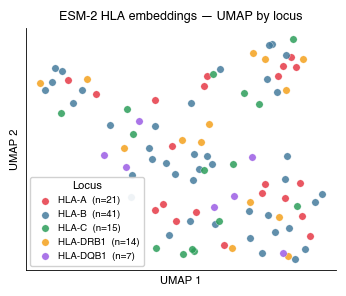

In [8]:
"""Figure 1 — UMAP colored by HLA locus."""

present_loci = [l for l in TARGET_LOCI if l in meta["locus"].values]

fig, ax = plt.subplots(figsize=(3.5, 3.0))

for locus in present_loci:
    mask = meta["locus"] == locus
    ax.scatter(
        meta.loc[mask, "umap1"],
        meta.loc[mask, "umap2"],
        c=LOCUS_COLORS[locus],
        s=28,
        alpha=0.85,
        linewidths=0.25,
        edgecolors="white",
        label=f"HLA-{locus}  (n={mask.sum()})",
        zorder=3,
    )

legend = ax.legend(
    title="Locus",
    loc="best",
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
    handletextpad=0.3,
    borderpad=0.5,
)
legend.get_title().set_fontweight("bold")

ax.set_xlabel("UMAP 1", labelpad=4)
ax.set_ylabel("UMAP 2", labelpad=4)
ax.set_title(
    "ESM-2 HLA embeddings — UMAP by locus",
    fontweight="bold", pad=6,
)

# Suppress tick values (UMAP units are arbitrary)
ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
save_fig(fig, "fig2a_umap_by_locus")
plt.show()

## 3. UMAP — Colored by Antigen Group (Within-Locus)

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2b_umap_by_antigen_group.png
  Saved paper/figures/fig2b_umap_by_antigen_group.pdf


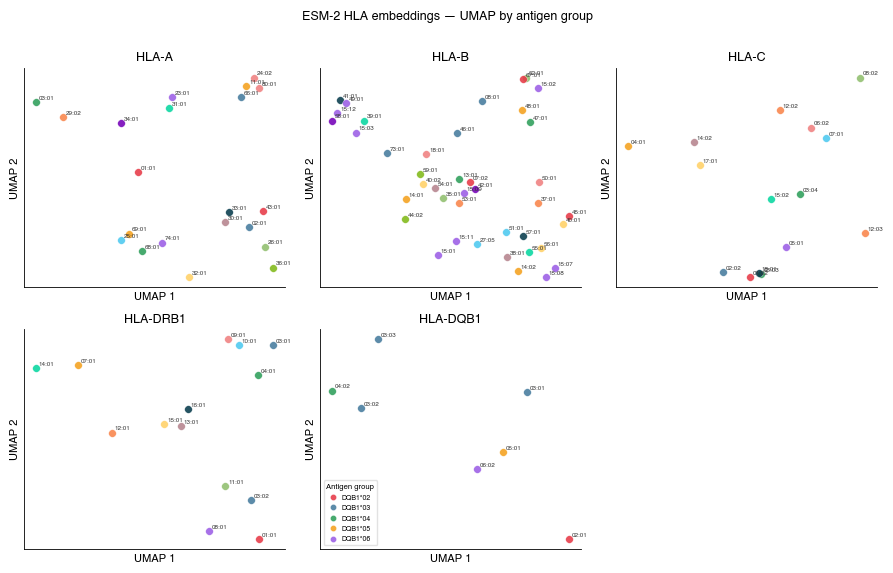

In [9]:
"""Figure 2 — one panel per locus, points colored by antigen group.

Alleles from the same broad antigen (e.g. A*02:01 and A*02:06)
should cluster together because they share the sequence backbone
of that antigen group.
"""

# Build a per-locus color map (qualitative, wrapped if > 10 groups)
QUALITATIVE_PALETTE = [
    "#E63946", "#457B9D", "#2D9E5A", "#F4A11D", "#9B5DE5",
    "#F08080", "#4CC9F0", "#90BE6D", "#F9844A", "#B5838D",
    "#06D6A0", "#FFD166", "#073B4C", "#7400B8", "#80B918",
]

n_loci = len(present_loci)
ncols = min(n_loci, 3)
nrows = (n_loci + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.0 * ncols, 2.8 * nrows),
    squeeze=False,
)

for ax_idx, locus in enumerate(present_loci):
    row, col = divmod(ax_idx, ncols)
    ax = axes[row][col]

    sub = meta[meta["locus"] == locus].copy()
    groups = sorted(sub["group"].unique())
    color_map = {g: QUALITATIVE_PALETTE[i % len(QUALITATIVE_PALETTE)]
                 for i, g in enumerate(groups)}

    for grp in groups:
        m = sub["group"] == grp
        ax.scatter(
            sub.loc[m, "umap1"],
            sub.loc[m, "umap2"],
            c=color_map[grp],
            s=30,
            alpha=0.88,
            linewidths=0.25,
            edgecolors="white",
            label=grp,
            zorder=3,
        )

    # Annotate each point with its short allele label
    for _, row_data in sub.iterrows():
        ax.annotate(
            row_data["short_label"],
            (row_data["umap1"], row_data["umap2"]),
            fontsize=4.5,
            color="#333333",
            xytext=(2, 2),
            textcoords="offset points",
            ha="left",
        )

    ax.set_title(f"HLA-{locus}", fontweight="bold", pad=5)
    ax.set_xlabel("UMAP 1", labelpad=3)
    ax.set_ylabel("UMAP 2", labelpad=3)
    ax.set_xticks([])
    ax.set_yticks([])

    if len(groups) <= 12:
        ax.legend(
            title="Antigen group",
            fontsize=5,
            title_fontsize=5.5,
            loc="best",
            frameon=True,
            framealpha=0.85,
            edgecolor="#dddddd",
            markerscale=0.8,
            handlelength=0.8,
            borderpad=0.4,
        )

# Hide unused axes
for ax_idx in range(n_loci, nrows * ncols):
    row, col = divmod(ax_idx, ncols)
    axes[row][col].set_visible(False)

fig.suptitle(
    "ESM-2 HLA embeddings — UMAP by antigen group",
    fontweight="bold", y=1.01, fontsize=9,
)
fig.tight_layout()
save_fig(fig, "fig2b_umap_by_antigen_group")
plt.show()

## 4. Cosine Similarity Matrix — Within Each Locus

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2c_cosine_sim_A.png
  Saved paper/figures/fig2c_cosine_sim_A.pdf


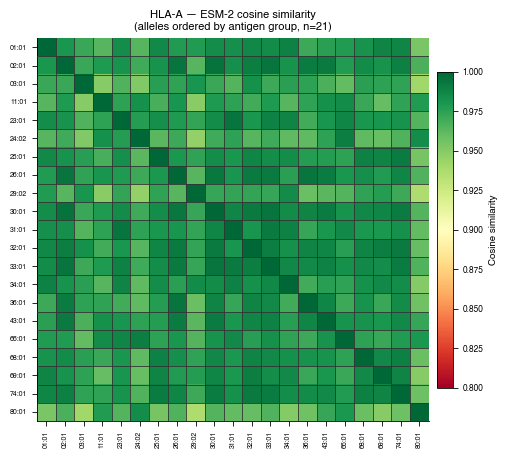

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2c_cosine_sim_B.png


  Saved paper/figures/fig2c_cosine_sim_B.pdf


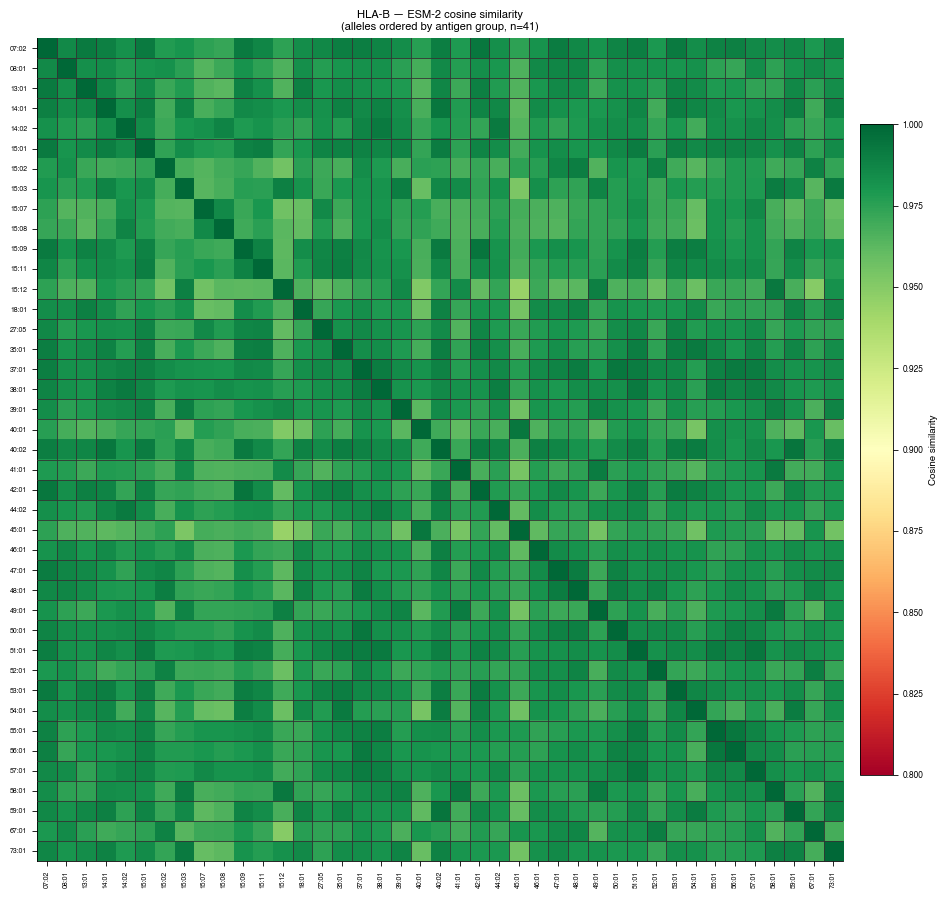

  Saved paper/figures/fig2c_cosine_sim_C.png


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2c_cosine_sim_C.pdf


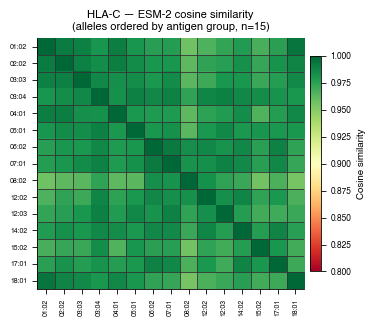

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2c_cosine_sim_DRB1.png


  Saved paper/figures/fig2c_cosine_sim_DRB1.pdf


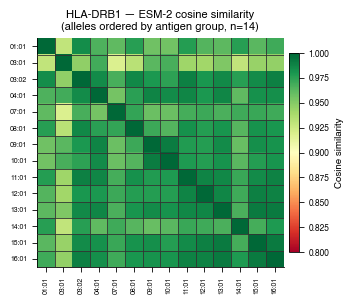

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2c_cosine_sim_DQB1.png
  Saved paper/figures/fig2c_cosine_sim_DQB1.pdf


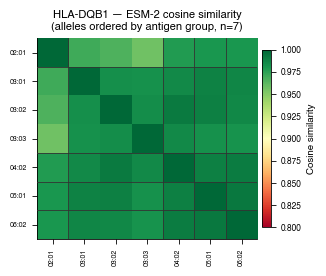

In [10]:
"""Compute cosine similarity matrices and rank-order alleles by antigen group.

Expected: alleles within the same antigen group (e.g. B*44:02 and B*44:03)
should show higher cosine similarity than alleles from different groups
(e.g. B*44:02 vs B*07:02).
"""

def cosine_similarity_matrix(emb: np.ndarray) -> np.ndarray:
    """Return N×N cosine similarity matrix from an N×D embedding matrix."""
    emb_n = normalize(emb, norm="l2")
    return emb_n @ emb_n.T


def order_by_group(sub_meta: pd.DataFrame) -> np.ndarray:
    """Return row indices that sort alleles by antigen group then alphabetically."""
    return sub_meta.sort_values(["group", "allele"]).index.map(
        lambda i: sub_meta.index.get_loc(i)
    ).to_numpy()


for locus in present_loci:
    mask = (meta["locus"] == locus).values
    sub_emb  = embeddings[mask]
    sub_meta = meta[mask].reset_index(drop=True)

    sim = cosine_similarity_matrix(sub_emb)
    order = order_by_group(sub_meta)
    sim_ord  = sim[np.ix_(order, order)]
    labels   = sub_meta.iloc[order]["short_label"].tolist()
    groups   = sub_meta.iloc[order]["group"].tolist()

    n = len(labels)
    fig_h = max(2.8, 0.22 * n)
    fig_w = fig_h + 0.5   # room for colorbar

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(
        sim_ord,
        vmin=0.80, vmax=1.0,
        cmap="RdYlGn",
        aspect="auto",
        interpolation="nearest",
    )

    # Axis tick labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_yticklabels(labels, fontsize=5)

    # Draw group boundaries as bold lines
    prev_grp = None
    for i, g in enumerate(groups):
        if g != prev_grp and i > 0:
            for spine_ax in (ax,):
                spine_ax.axhline(i - 0.5, color="#333333", lw=0.6, zorder=5)
                spine_ax.axvline(i - 0.5, color="#333333", lw=0.6, zorder=5)
        prev_grp = g

    cbar = fig.colorbar(im, ax=ax, fraction=0.038, pad=0.02)
    cbar.set_label("Cosine similarity", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    ax.set_title(
        f"HLA-{locus} — ESM-2 cosine similarity\n"
        f"(alleles ordered by antigen group, n={n})",
        fontweight="bold", pad=6, fontsize=8,
    )

    fig.tight_layout()
    save_fig(fig, f"fig2c_cosine_sim_{locus}")
    plt.show()

## 5. Quantitative Validation — Within-Group vs Between-Group Similarity

In [11]:
"""Test the core hypothesis: within-antigen-group cosine similarity >  
between-group similarity for all loci.

This is the biological validation: alleles that share a serological
antigen group (and thus a common protein backbone) should be closer
in ESM-2 embedding space than alleles from different groups.
"""

from scipy import stats as scipy_stats

results = []

for locus in present_loci:
    mask = (meta["locus"] == locus).values
    sub_emb  = embeddings[mask]
    sub_meta = meta[mask].reset_index(drop=True)

    sim = cosine_similarity_matrix(sub_emb)
    groups_arr = sub_meta["group"].values
    n = len(groups_arr)

    within, between = [], []
    for i in range(n):
        for j in range(i + 1, n):
            s = float(sim[i, j])
            if groups_arr[i] == groups_arr[j]:
                within.append(s)
            else:
                between.append(s)

    # Skip loci with only one allele per group (no within-group pairs)
    if not within:
        results.append({
            "locus": locus, "n_alleles": n,
            "within_mean": float("nan"), "between_mean": float("nan"),
            "delta": float("nan"), "p_value": float("nan"),
            "significant": False,
        })
        continue

    stat, p = scipy_stats.mannwhitneyu(within, between, alternative="greater")

    results.append({
        "locus":        locus,
        "n_alleles":    n,
        "within_mean":  float(np.mean(within)),
        "between_mean": float(np.mean(between)),
        "delta":        float(np.mean(within) - np.mean(between)),
        "p_value":      float(p),
        "significant":  bool(p < 0.05),
    })

res_df = pd.DataFrame(results).set_index("locus")
pd.options.display.float_format = "{:.4f}".format
print(res_df.to_string())

       n_alleles  within_mean  between_mean   delta  p_value  significant
locus                                                                    
A             21          NaN           NaN     NaN      NaN        False
B             41       0.9734        0.9789 -0.0055   0.9993        False
C             15       0.9849        0.9787  0.0062   0.1385        False
DRB1          14       0.9465        0.9721 -0.0256   0.9121        False
DQB1           7       0.9830        0.9824  0.0006   0.6654        False


  Saved paper/figures/fig2d_within_vs_between_similarity.png


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


  Saved paper/figures/fig2d_within_vs_between_similarity.pdf


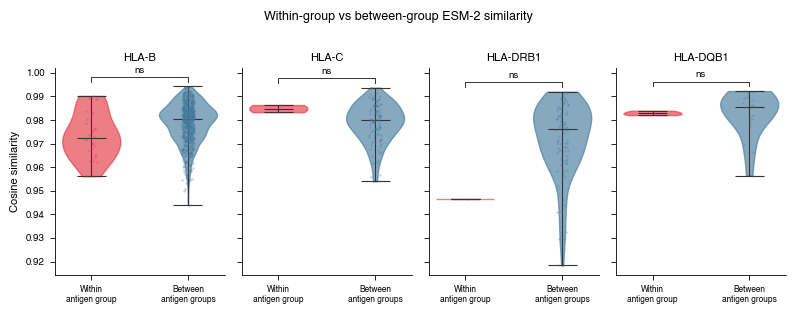


Summary table:
       n_alleles  within_mean  between_mean   delta  p_value  significant
locus                                                                    
A             21          NaN           NaN     NaN      NaN        False
B             41       0.9734        0.9789 -0.0055   0.9993        False
C             15       0.9849        0.9787  0.0062   0.1385        False
DRB1          14       0.9465        0.9721 -0.0256   0.9121        False
DQB1           7       0.9830        0.9824  0.0006   0.6654        False


In [12]:
"""Figure 3 — violin / strip comparison of within-group vs between-group similarity."""

loci_with_pairs = [r["locus"] for r in results if not np.isnan(r["within_mean"])]

if not loci_with_pairs:
    print("No loci with within-group allele pairs — skipping violin plot.")
else:
    n_loci_p = len(loci_with_pairs)
    fig, axes = plt.subplots(
        1, n_loci_p,
        figsize=(2.0 * n_loci_p, 3.0),
        sharey=True,
        squeeze=False,
    )

    for ax_i, locus in enumerate(loci_with_pairs):
        ax = axes[0][ax_i]
        mask = (meta["locus"] == locus).values
        sub_emb  = embeddings[mask]
        sub_meta = meta[mask].reset_index(drop=True)

        sim = cosine_similarity_matrix(sub_emb)
        groups_arr = sub_meta["group"].values
        n = len(groups_arr)

        within, between = [], []
        for i in range(n):
            for j in range(i + 1, n):
                s = float(sim[i, j])
                if groups_arr[i] == groups_arr[j]:
                    within.append(s)
                else:
                    between.append(s)

        colors = ["#E63946", "#457B9D"]
        data   = [within, between]
        labels = ["Within\nantigen group", "Between\nantigen groups"]

        parts = ax.violinplot(
            data, positions=[0, 1],
            showmedians=True, showextrema=True,
            widths=0.6,
        )
        for pc, col in zip(parts["bodies"], colors):
            pc.set_facecolor(col)
            pc.set_alpha(0.65)
            pc.set_edgecolor(col)
        for part_name in ("cmedians", "cmins", "cmaxes", "cbars"):
            parts[part_name].set_color("#333333")
            parts[part_name].set_linewidth(0.8)

        # Strip dots
        rng = np.random.default_rng(0)
        for xi, (vals, col) in enumerate(zip(data, colors)):
            jitter = rng.uniform(-0.06, 0.06, len(vals))
            ax.scatter(
                np.full(len(vals), xi) + jitter, vals,
                c=col, s=3, alpha=0.35, linewidths=0, zorder=4,
            )

        # Significance annotation
        row = res_df.loc[locus]
        p_val = row["p_value"]
        if not np.isnan(p_val):
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            y_top = max(max(within), max(between)) + 0.002
            ax.plot([0, 0, 1, 1], [y_top, y_top + 0.002, y_top + 0.002, y_top],
                    c="#333333", lw=0.7)
            ax.text(0.5, y_top + 0.003, sig,
                    ha="center", va="bottom", fontsize=7, fontweight="bold")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(labels, fontsize=6)
        ax.set_title(f"HLA-{locus}", fontweight="bold", fontsize=8, pad=5)
        if ax_i == 0:
            ax.set_ylabel("Cosine similarity", labelpad=4)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    fig.suptitle(
        "Within-group vs between-group ESM-2 similarity",
        fontweight="bold", y=1.02, fontsize=9,
    )
    fig.tight_layout()
    save_fig(fig, "fig2d_within_vs_between_similarity")
    plt.show()

    print("\nSummary table:")
    print(res_df[["n_alleles", "within_mean", "between_mean", "delta", "p_value", "significant"]].to_string())

## 6. Top-K Nearest Neighbours (Qualitative Sanity Check)

In [13]:
"""For a set of well-known alleles, show the K most similar alleles.

Biologically expected:
- A*02:01 nearest neighbours should be other A*02:xx alleles (same supertypes)
- DRB1*15:01 and DRB1*16:01 are both DR2 splits and should be close
- B*57:01 and B*58:01 are both Bw4 and antigen-related → should be close
"""
K = 5

QUERY_ALLELES = ["A*02:01", "B*07:02", "DRB1*15:01"]

# Compute full cosine similarity
emb_n = normalize(embeddings, norm="l2")
sim_all = emb_n @ emb_n.T   # (N, N)

allele_list = available
allele_to_idx = {a: i for i, a in enumerate(allele_list)}

print(f"Top-{K} nearest neighbours by ESM-2 cosine similarity\n")
print("-" * 55)

for query in QUERY_ALLELES:
    if query not in allele_to_idx:
        print(f"{query}: not in cache — skipping.")
        continue

    qi = allele_to_idx[query]
    sims = sim_all[qi].copy()
    sims[qi] = -1           # exclude self
    top_k = np.argsort(sims)[::-1][:K]

    print(f"Query: {query}  (locus: {_locus(query)}, group: {_antigen_group(query)})")
    for rank, j in enumerate(top_k, 1):
        neighbour = allele_list[j]
        same_grp  = _antigen_group(neighbour) == _antigen_group(query)
        marker    = "✓" if same_grp else " "
        print(f"  {rank}. {neighbour:<20}  sim={sims[j]:.4f}  {marker}")
    print()

Top-5 nearest neighbours by ESM-2 cosine similarity

-------------------------------------------------------
Query: A*02:01  (locus: A, group: A*02)
  1. A*30:01               sim=0.9953   
  2. DRB1*03:02            sim=0.9947   
  3. A*33:01               sim=0.9945   
  4. A*26:01               sim=0.9944   
  5. B*51:01               sim=0.9942   

Query: B*07:02  (locus: B, group: B*07)
  1. DQB1*05:01            sim=0.9951   
  2. C*03:04               sim=0.9936   
  3. DRB1*13:01            sim=0.9934   
  4. B*42:01               sim=0.9930   
  5. DQB1*06:02            sim=0.9929   

Query: DRB1*15:01  (locus: DRB1, group: DRB1*15)
  1. B*40:02               sim=0.9936   
  2. C*03:04               sim=0.9928   
  3. B*15:09               sim=0.9926   
  4. B*07:02               sim=0.9925   
  5. A*01:01               sim=0.9924   



## 7. Figure Summary

In [14]:
"""Print a list of all saved figures."""
figs = sorted(FIGURES_DIR.glob("*.png"))
print(f"Saved {len(figs)} figures to {FIGURES_DIR.relative_to(ROOT)}:")
for f in figs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45}  {size_kb:>7.1f} KB")

Saved 8 figures to paper/figures:
  fig2a_umap_by_locus.png                           82.8 KB
  fig2b_umap_by_antigen_group.png                  213.6 KB
  fig2c_cosine_sim_A.png                           105.7 KB
  fig2c_cosine_sim_B.png                           189.9 KB
  fig2c_cosine_sim_C.png                            78.6 KB
  fig2c_cosine_sim_DQB1.png                         57.7 KB
  fig2c_cosine_sim_DRB1.png                         74.1 KB
  fig2d_within_vs_between_similarity.png           164.0 KB
